## 探讨蒙特卡罗模拟在高维数据中的困境

在第三节中，我们提及了使用狄利克雷分布后的蒙特卡洛模拟在大量模拟后依然出现了明显的真空带，下面我们将解释这种情况的根本原因

首先从三个资产开始，可视化的理解蒙特卡罗模拟采样的原理
*数据来自： https://www.lianxh.cn/news/bb9816c5bebae.html 《Stata：投资组合有效边界》*

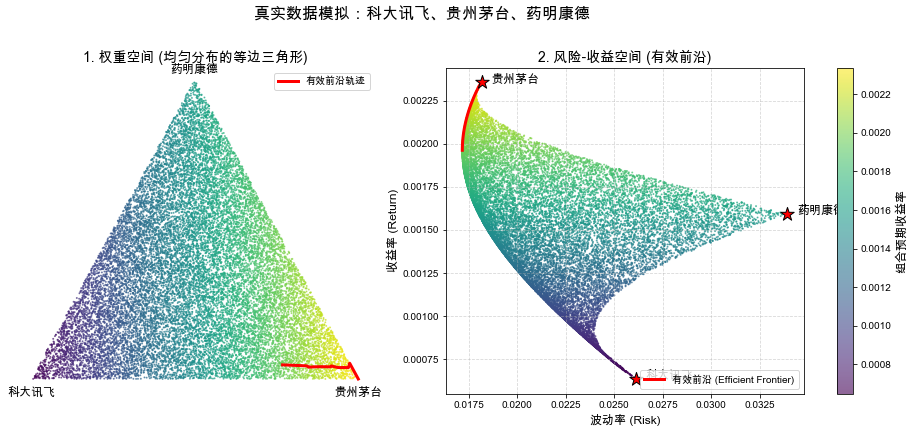

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Windows用黑体，Mac用户请改为 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

# 1. 导入真实数据
# 资产顺序：[科大讯飞, 贵州茅台, 药明康德]
returns = np.array([0.00063598, 0.00235508, 0.00159318]) 

# 对称协方差矩阵补全
cov_matrix = np.array([
    [0.00068277, 0.00018373, 0.00032823],
    [0.00018373, 0.00032969, 0.00023092],
    [0.00032823, 0.00023092, 0.00115149]
])

# 2. 蒙特卡洛模拟：生成均匀分布的权重
n_simulations = 20000  # 增加点数让边缘更清晰
weights = np.random.dirichlet(np.ones(3), size=n_simulations)

# 3. 计算每个组合的收益率和波动率
# 组合收益率公式: \( \mu_p = \mathbf{w}^T \boldsymbol{\mu} \)
port_returns = np.dot(weights, returns)
port_risks = np.zeros(n_simulations)
for i in range(n_simulations):
    # 组合风险公式: \( \sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}} \)
    port_risks[i] = np.sqrt(np.dot(weights[i].T, np.dot(cov_matrix, weights[i])))

# ================= 新增：计算有效前沿 =================
def portfolio_volatility(w, cov_mat):
    """计算组合波动率"""
    return np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))

def get_efficient_frontier(returns_array, cov_mat, num_points=50):
    """通过二次规划求解有效前沿"""
    # 寻找全局最小方差组合 (Global Minimum Variance Portfolio)
    num_assets = len(returns_array)
    args = (cov_mat,)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    
    min_var_result = sco.minimize(portfolio_volatility, num_assets * [1. / num_assets,], 
                                  args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    min_vol_return = np.sum(min_var_result.x * returns_array)
    max_return = np.max(returns_array)
    
    # 在最小方差收益率和最大收益率之间生成目标收益率序列
    target_returns = np.linspace(min_vol_return, max_return, num_points)
    
    frontier_weights = []
    frontier_risks = []
    
    for target in target_returns:
        # 约束条件：1. 权重和为1; 2. 收益率等于目标收益率
        # 约束公式: \( \sum w_i = 1 \) 且 \( \mathbf{w}^T \boldsymbol{\mu} = \mu_{target} \)
        cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                {'type': 'eq', 'fun': lambda x: np.sum(x * returns_array) - target})
        
        res = sco.minimize(portfolio_volatility, num_assets * [1. / num_assets,], 
                           args=args, method='SLSQP', bounds=bounds, constraints=cons)
        frontier_weights.append(res.x)
        frontier_risks.append(res.fun)
        
    return np.array(frontier_weights), np.array(frontier_risks), target_returns

# 获取有效前沿的权重、风险和收益率
ef_weights, ef_risks, ef_returns = get_efficient_frontier(returns, cov_matrix)

# 将有效前沿的权重映射到2D三角形平面
ef_x_triangle = ef_weights[:, 1] + 0.5 * ef_weights[:, 2]
ef_y_triangle = (np.sqrt(3) / 2) * ef_weights[:, 2]
# ======================================================

# 4. 绘图准备：将3D权重(w1,w2,w3)投影到2D等边三角形平面上
# 左下: 科大讯飞(0,0)，右下: 贵州茅台(1,0)，正上: 药明康德(0.5, 0.866)
x_triangle = weights[:, 1] + 0.5 * weights[:, 2]
y_triangle = (np.sqrt(3) / 2) * weights[:, 2]

# 5. 开始绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左图：权重三角形
scatter1 = ax1.scatter(x_triangle, y_triangle, c=port_returns, cmap='viridis', s=1, alpha=0.6)
# 绘制有效前沿在权重空间的轨迹
ax1.plot(ef_x_triangle, ef_y_triangle, color='red', linewidth=3, label='有效前沿轨迹')
ax1.set_title("1. 权重空间 (均匀分布的等边三角形)", fontsize=14)
ax1.text(0, -0.05, '科大讯飞', ha='center', fontsize=12, fontweight='bold')
ax1.text(1, -0.05, '贵州茅台', ha='center', fontsize=12, fontweight='bold')
ax1.text(0.5, np.sqrt(3)/2 + 0.02, '药明康德', ha='center', fontsize=12, fontweight='bold')
ax1.axis('off') 
ax1.legend(loc='upper right')

# 右图：风险-收益散点图
scatter2 = ax2.scatter(port_risks, port_returns, c=port_returns, cmap='viridis', s=1, alpha=0.6)
# 绘制有效前沿曲线
ax2.plot(ef_risks, ef_returns, color='red', linewidth=3, label='有效前沿 (Efficient Frontier)')
ax2.set_title("2. 风险-收益空间 (有效前沿)", fontsize=14)
ax2.set_xlabel("波动率 (Risk)", fontsize=12)
ax2.set_ylabel("收益率 (Return)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# 标注三个单一资产在右图中的位置
asset_names = ['科大讯飞', '贵州茅台', '药明康德']
asset_risks = np.sqrt(np.diag(cov_matrix))
for i in range(3):
    ax2.scatter(asset_risks[i], returns[i], color='red', marker='*', s=200, edgecolor='black', zorder=5)
    ax2.text(asset_risks[i] + 0.0005, returns[i], asset_names[i], fontsize=12, fontweight='bold')

# 添加颜色条
cbar = fig.colorbar(scatter2, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('组合预期收益率', fontsize=12)

plt.suptitle("真实数据模拟：科大讯飞、贵州茅台、药明康德", fontsize=16, y=1.02)
plt.show()


1. **权重空间（左图）：** 对于三个资产（科大讯飞、贵州茅台、药明康德），其投资权重
   $$
   \mathbf{w} = [w_1, w_2, w_3]^T
   $$ 
   满足归一化条件 
   $$  
   \ w_1 + w_2 + w_3 = 1
   $$
   $$
   \ w_i \ge 0
   $$
   在几何上，这构成了一个二维的标准单纯形（等边三角形）。图中均匀分布的散点代表我们在此空间内进行了**均匀随机采样**。
2. **风险-收益空间（右图）：** 这是目标映射空间。左图中的每一个权重组合，都被投射为右图中的一个点（X轴为波动率，Y轴为预期收益率）
3. 最重要的观察则是，有效前沿曲线在权重空间上最终走向了边界，最后达到了属于贵州茅台的顶点，这带给了我们一些启示，在一些特定情况下，有效前沿曲线会走向权重空间的`表面`，事实上，这个结论在高维情况下也是成立的，例如在四个资产下，权重空间为3维里的正四面体，有效前沿曲线总会走向表面，在限制做空的条件下总是成立的，在这里不做严谨的数学证明



### 有效前沿曲线的这种性质带来了什么麻烦？
## AI辅助证明
我们可以通过概率论中的狄利克雷分布（Dirichlet Distribution）**和**切比雪夫不等式（Chebyshev's Inequality）来严格证明：随着资产维度 $N$ 的增加，随机生成的权重会极度向等权重组合 $w_i = 1/N$聚集，而极难产生极端的权重。

以下是数学证明过程：

### 1. 定义随机权重的概率分布
要在单纯形上“均匀”地随机撒点，最标准的数学方法是使用参数全为 1 的狄利克雷分布。设权重向量为 
$$
\mathbf{w} = (w_1, w_2, \dots, w_N)\
$$
则：
$$
\mathbf{w} \sim \text{Dirichlet}(1, 1, \dots, 1)
$$

### 2. 求单个资产权重 $w_i$ 的边缘分布
根据狄利克雷分布的性质，任意单个权重 $w_i$ 的边缘分布服从**贝塔分布（Beta Distribution）**：
$$
w_i \sim \text{Beta}(\alpha_i, \alpha_0 - \alpha_i)
$$
其中 $$ \\alpha_i = 1\ $$  $$ \\alpha_0 = \sum_{j=1}^N \alpha_j = N\ $$ 
因此，单个权重的分布为：
$$
w_i \sim \text{Beta}(1, N-1)
$$

### 3. 计算期望与方差
根据 Beta 分布的数学期望和方差公式，我们可以求出 \(w_i\) 的均值和方差：

**期望（均值）：**
$$
\mathbb{E}[w_i] = \frac{1}{1 + (N-1)} = \frac{1}{N}
$$
这说明，无论维度多高，随机生成的单个资产权重的期望值始终是等权重 \(1/N\)。

**方差：**
$$
\text{Var}(w_i) = \frac{1 \cdot (N-1)}{(1 + N - 1)^2 (1 + N - 1 + 1)} = \frac{N-1}{N^2(N+1)}
$$
当 \(N\) 很大时，方差的渐近行为是：
$$
\text{Var}(w_i) \approx \frac{N}{N^3} = \frac{1}{N^2}
$$

### 4. 利用切比雪夫不等式证明“中心聚集”
切比雪夫不等式告诉我们，对于任意随机变量 $X$ 和任意正数 $\epsilon > 0$，其偏离均值的概率满足：
$$
\mathbb{P}(|X - \mathbb{E}[X]| \ge \epsilon) \le \frac{\text{Var}(X)}{\epsilon^2}
$$

将 $w_i$ 的期望和方差代入：
$$
\mathbb{P}\left(\left|w_i - \frac{1}{N}\right| \ge \epsilon\right) \le \frac{N-1}{N^2(N+1)\epsilon^2} < \frac{1}{N^2 \epsilon^2}
$$

**结论：**
当资产数量 \(N\) 增加时，不等式右侧以 $\mathcal{O}(1/N^2)$ 的速度迅速趋近于 0。
这意味着：**在高维情况下，任意一个资产的权重 w_i 偏离等权重 1/N 的概率几乎为 0。**


以上证明说明了我们观察到的现象，因有效前沿曲线几乎总是在某一段开始经过标准型表面，这意味着某个、或者某几个资产的权重 $wi = 0$,而在高维数据中，几乎总是无法随机生成到这种数据，所以观察到靠近有效前沿曲线和模拟数据之间的真空带

我们可以引入更高维的数据来应证我们的观察
数据来自：TWSE 笔者自行爬取，本文档不提供爬虫代码

正在加载和处理数据...
随机抽取的股票文件: ['00648R_元大S&P500反1_2015_至今.csv', '0051_元大中型100_2015_至今.csv', '00652_富邦印度_2015_至今.csv', '00712_復華富時不動產(原簡稱:FH富時不動產)_2015_至今.csv', '00682U_期元大美元指數_2015_至今.csv', '00656R_國泰中國A50反1_2015_至今.csv', '00655L_國泰中國A50正2_2015_至今.csv', '00717_富邦美國特別股_2015_至今.csv', '00638R_元大滬深300反1_2015_至今.csv', '00663L_國泰臺灣加權正2_2015_至今.csv', '00650L_復華香港正2(原簡稱:FH香港正2)_2015_至今.csv', '00735_國泰臺韓科技_2015_至今.csv']
成功合并并计算 12 只股票的收益率: 元大S&P500反1, 元大中型100, 富邦印度, 復華富時不動產(原簡稱:FH富時不動產), 期元大美元指數, 國泰中國A50反1, 國泰中國A50正2, 富邦美國特別股, 元大滬深300反1, 國泰臺灣加權正2, 復華香港正2(原簡稱:FH香港正2), 國泰臺韓科技
正在进行蒙特卡洛模拟...
正在计算数值解的有效前沿曲线及极值点...
计算完成，正在绘制图表...


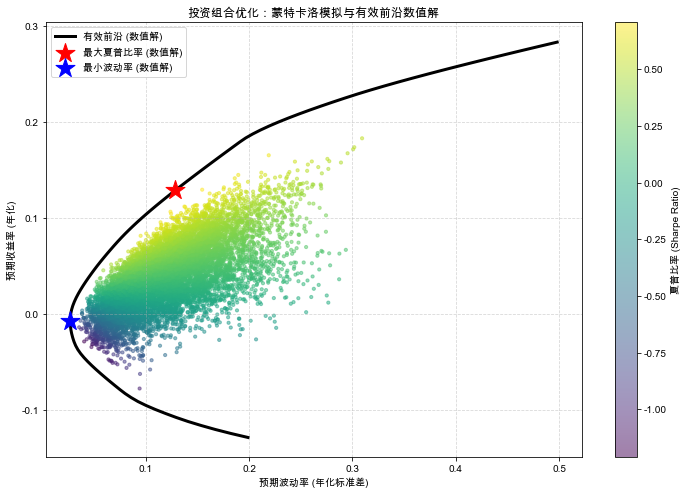

In [57]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco

# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

RISK_FREE_RATE = 0.02  # 无风险利率

def load_and_process_data(data_dir, n_stocks):
    """从指定目录随机读取N个股票的CSV文件并合并"""
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"找不到目录: {data_dir}")
        
    all_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    
    if len(all_files) < n_stocks:
        raise ValueError(f"目录中的CSV文件数量 ({len(all_files)}) 少于请求的股票数量 ({n_stocks})")
        
    selected_files = random.sample(all_files, n_stocks)
    print(f"随机抽取的股票文件: {selected_files}")
    
    df_list = []
    stock_names = []
    
    for file in selected_files:
        file_path = os.path.join(data_dir, file)
        
        try:
            df = pd.read_csv(file_path, encoding='utf-8')
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(file_path, encoding='big5')
            except UnicodeDecodeError:
                df = pd.read_csv(file_path, encoding='cp950')
        
        df.columns = df.columns.str.strip()
        
        if 'date' not in df.columns or 'close' not in df.columns:
            continue
            
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        
        # 去除重复的日期索引，保留最后一条
        df = df[~df.index.duplicated(keep='last')]
        
        if 'stock_name' in df.columns and not df['stock_name'].empty:
            stock_name = str(df['stock_name'].iloc[0]).strip()
        elif 'stock_no' in df.columns and not df['stock_no'].empty:
            stock_name = str(df['stock_no'].iloc[0]).strip()
        else:
            stock_name = os.path.splitext(file)[0]
            
        stock_names.append(stock_name)
        df_close = df[['close']].rename(columns={'close': stock_name})
        df_list.append(df_close)
        
    if not df_list:
        raise ValueError("没有成功加载任何有效的股票数据。")
        
    combined_df = pd.concat(df_list, axis=1)
    combined_df.ffill(inplace=True)
    combined_df.dropna(inplace=True)
    
    return combined_df, stock_names

def portfolio_performance(weights, mean_returns, cov_matrix):
    """计算给定权重下的投资组合预期收益率和波动率"""
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

def monte_carlo_simulation(returns, num_portfolios=10000):
    """使用狄利克雷分布进行蒙特卡洛模拟"""
    n_stocks = len(returns.columns)
    mean_returns = returns.mean() * 252
    cov_matrix = returns.cov() * 252
    
    results = np.zeros((3, num_portfolios))
    weights_array = np.random.dirichlet(np.ones(n_stocks), num_portfolios)
    
    for i in range(num_portfolios):
        weights = weights_array[i]
        portfolio_return, portfolio_std_dev = portfolio_performance(weights, mean_returns, cov_matrix)
        sharpe_ratio = (portfolio_return - RISK_FREE_RATE) / portfolio_std_dev
        
        results[0, i] = portfolio_return
        results[1, i] = portfolio_std_dev
        results[2, i] = sharpe_ratio
        
    return results, weights_array, mean_returns, cov_matrix

def optimize_max_sharpe(mean_returns, cov_matrix):
    """数值解：寻找最大夏普比率的投资组合"""
    n_stocks = len(mean_returns)
    
    # 目标函数：最小化负的夏普比率（等同于最大化夏普比率）
    def neg_sharpe(weights):
        p_ret, p_vol = portfolio_performance(weights, mean_returns, cov_matrix)
        return -(p_ret - RISK_FREE_RATE) / p_vol
        
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n_stocks))
    initial_guess = n_stocks * [1. / n_stocks]
    
    result = sco.minimize(neg_sharpe, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    opt_ret, opt_vol = portfolio_performance(result.x, mean_returns, cov_matrix)
    return opt_ret, opt_vol

def optimize_min_volatility(mean_returns, cov_matrix):
    """数值解：寻找最小波动率的投资组合"""
    n_stocks = len(mean_returns)
    
    def get_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
        
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n_stocks))
    initial_guess = n_stocks * [1. / n_stocks]
    
    result = sco.minimize(get_volatility, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    opt_ret, opt_vol = portfolio_performance(result.x, mean_returns, cov_matrix)
    return opt_ret, opt_vol

def calculate_efficient_frontier(mean_returns, cov_matrix, points=100):
    """使用数值优化方法计算有效前沿曲线"""
    n_stocks = len(mean_returns)
    
    def minimize_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), points)
    efficient_volatilities = []
    
    bounds = tuple((0, 1) for _ in range(n_stocks))
    initial_guess = n_stocks * [1. / n_stocks]
    
    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: portfolio_performance(x, mean_returns, cov_matrix)[0] - target}
        )
        result = sco.minimize(minimize_volatility, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        
        if result.success:
            efficient_volatilities.append(result.fun)
        else:
            efficient_volatilities.append(np.nan)
            
    return target_returns, efficient_volatilities

def plot_efficient_frontier(results, ef_returns, ef_volatilities, max_sharpe_pt, min_vol_pt):
    """绘制蒙特卡洛模拟散点图及数值解有效前沿曲线，并在数值解上标注极值点"""
    returns = results[0, :]
    volatility = results[1, :]
    sharpe = results[2, :]
    
    plt.figure(figsize=(12, 8))
    
    # 1. 绘制蒙特卡洛模拟散点图
    scatter = plt.scatter(volatility, returns, c=sharpe, cmap='viridis', marker='o', s=10, alpha=0.5)
    plt.colorbar(scatter, label='夏普比率 (Sharpe Ratio)')
    
    # 2. 绘制数值解的有效前沿曲线
    plt.plot(ef_volatilities, ef_returns, 'k-', linewidth=3, label='有效前沿 (数值解)')
    
    # 3. 在数值解上标注关键点
    plt.scatter(max_sharpe_pt[1], max_sharpe_pt[0], 
                marker='*', color='r', s=400, label='最大夏普比率 (数值解)', zorder=5)
    plt.scatter(min_vol_pt[1], min_vol_pt[0], 
                marker='*', color='b', s=400, label='最小波动率 (数值解)', zorder=5)
    
    plt.title('投资组合优化：蒙特卡洛模拟与有效前沿数值解')
    plt.xlabel('预期波动率 (年化标准差)')
    plt.ylabel('预期收益率 (年化)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def main():
    data_dir = './data'
    
    while True:
        try:
            n_stocks = int(input("请输入想要从 data 文件夹中随机抽取的股票数量 N: "))
            if n_stocks <= 1:
                print("股票数量必须大于1才能构建投资组合，请重新输入。")
                continue
            break
        except ValueError:
            print("请输入有效的整数。")
            
    num_portfolios = 10000 
    
    print("正在加载和处理数据...")
    try:
        prices_df, stock_names = load_and_process_data(data_dir, n_stocks)
    except Exception as e:
        print(f"数据加载失败: {e}")
        return
        
    returns_df = prices_df.pct_change().dropna()
    
    print(f"成功合并并计算 {len(stock_names)} 只股票的收益率: {', '.join(stock_names)}")
    
    print("正在进行蒙特卡洛模拟...")
    results, weights, mean_returns, cov_matrix = monte_carlo_simulation(returns_df, num_portfolios=num_portfolios)
    
    print("正在计算数值解的有效前沿曲线及极值点...")
    ef_returns, ef_volatilities = calculate_efficient_frontier(mean_returns, cov_matrix, points=100)
    
    # 精确求解最大夏普比率和最小波动率点
    max_sharpe_ret, max_sharpe_vol = optimize_max_sharpe(mean_returns, cov_matrix)
    min_vol_ret, min_vol_vol = optimize_min_volatility(mean_returns, cov_matrix)
    
    print("计算完成，正在绘制图表...")
    plot_efficient_frontier(
        results, 
        ef_returns, 
        ef_volatilities, 
        max_sharpe_pt=(max_sharpe_ret, max_sharpe_vol), 
        min_vol_pt=(min_vol_ret, min_vol_vol)
    )

if __name__ == "__main__":
    
    main()

实际上随着维度增加，我们总是能观察到这种真空现象，因此通过$alpha= 1$狄利克雷分布来完整刻画有效前沿曲线是不可取的

## 如何改进？
一个是简单的通过凸优化方法，就可以描绘有效前沿曲线，python工具已经相当成熟，这种方法对于大样本也一样有效，另一种则是可以通过调整狄利克雷函数的$alpha$参数，让他小于0，强迫生成边缘数值，就可以模拟出效果，不过这种模拟相对不稳定，但也不失为一种方案